# Points to pores - 1

***

Point distributions can be used to create porous media in 2D/3D where points are replaced by pores. This converts a given `tostada.PointDistribution` to `tostada.PhaseDistribution`. Currently, there are two ways in which this is done:

1. Dilating points with identical spheres (disks in 2D) of radius R.

2. Using points to construct a Voronoi network and dilating the network (lines).

Here, we shall cover the first case. Refer to points_pores_2.ipynb for constructing phases with Voronoi networks.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tostada as tost

### 1. Dilation with identical spheres/disks

Let us first define a point process in 3D. Here, we choose a random-sequential adsorption (RSA) process. A Monte-Carlo algorithm deposits each point sequentially based on probability function characteristic of this process. 

In [ ]:
process = tost.Pointprocess(BoxSize=7, # Size of the simulation domain. If scalar, chooses Lz based on self.is_3D
                       diameter=0.3, # diameter of the spheres/pores
                       ax = 0.45, # Mean inter-particle distance
                       is_3D = True) # Lets tostada know the simulation is 3D

points = process.RandomSequentialAdsorption() #runs for over 2 minutes

Estimated particles to be deposited=3764 with mean inter-particle distance=0.45


number of experiments:1025210): |███---------------------------| 10.3% Current FF=10.974 of 10.974


Since the point distribution is now in 3D, a 3D scatter plot is necessary for visualization.

2025-07-18 20:27:35.832 (   0.603s) [    7630745A9600]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


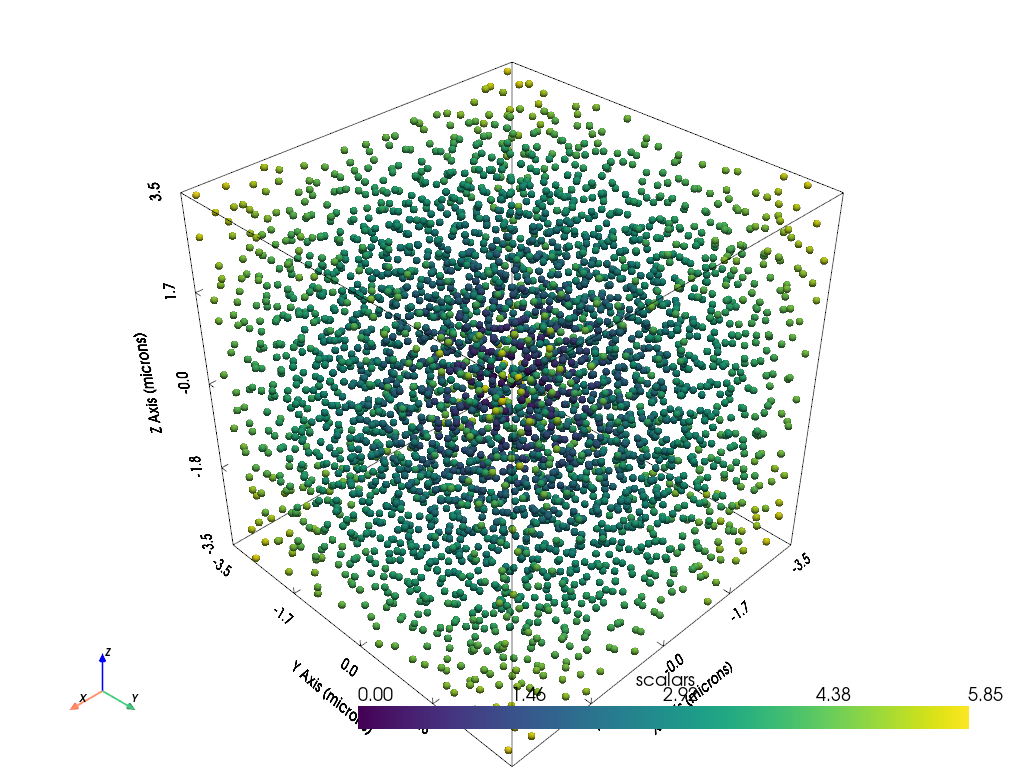

In [3]:
import pyvista as pv
pv.set_jupyter_backend("static")

point_cloud = pv.PolyData(points.positions)

# Optional: add scalars for coloring
scalars = np.linalg.norm(points.positions, axis=1)
point_cloud['scalars'] = scalars

# Plot
plotter = pv.Plotter()
plotter.add_mesh(point_cloud, render_points_as_spheres=True, point_size=8, scalars='scalars')
plotter.show_axes()
plotter.show_bounds(
    xtitle='X Axis (microns)',
    ytitle='Y Axis (microns)',
    ztitle='Z Axis (microns)',
    location='outer', 
    all_edges=True,          
    font_size=12,
)
plotter.show()

The scatter plot above only quantitatively shows the distribution of points in 3D. A better way to visualize the distribution here is rather in the fourier-space through a 3D structure-factor, $\tilde{S}(q)$. The choice of 2D vs 3D structure-factor is made on the fly based on `self.is_3D`.

`tostada.plot_util` can be used to visualize the reciprocal space. 

3D data. Plotting for qy=0 slice


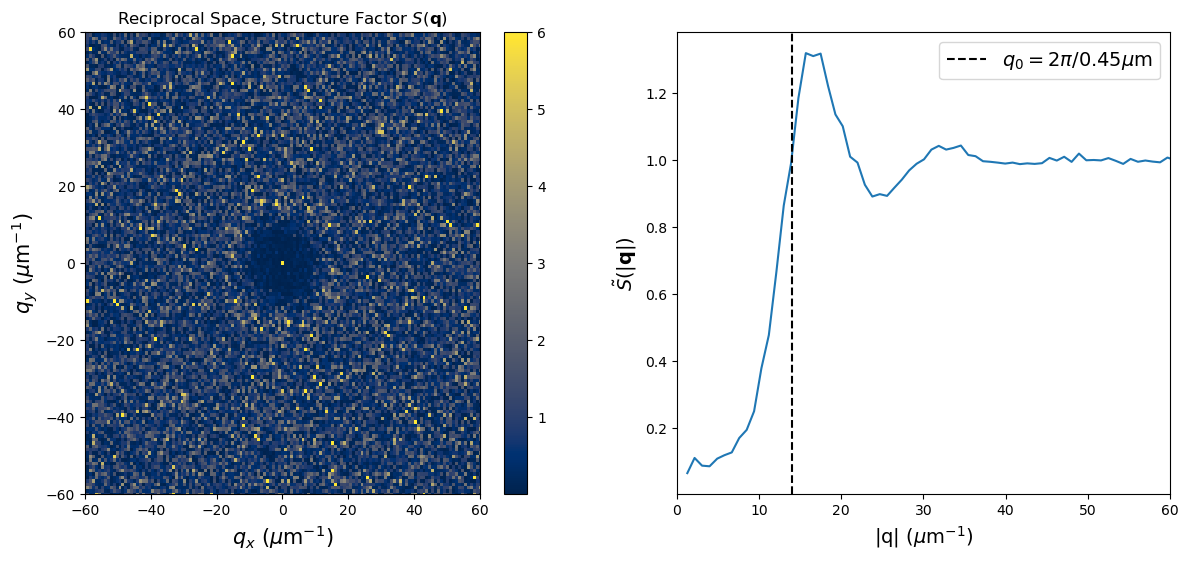

In [ ]:
fig = tost.Visualize(points)
ax = fig.plot_reciprocal_space(vmax=6)
ax[1].axvline(x=2*np.pi/process.ax,linestyle='--',color='black',label='$q_0=2\pi/0.45\mu$m')
ax[1].legend(fontsize=14)

The characteristic peak at $q_0 = 2\pi/0.45\mu m$ verifies the correctness of the algorithm in 3D.

The `PointDistribution` created above can be used to create a `PhaseDistribution` using `PointDistribution.Phaseobject()`. 

#### Case i) Avoid boundary interaction: For cases where the pores should avoid touching any boundary.

In [6]:
X = points.Phaseobject(dx=0.01) # resolution : 0.01 microns

3D Data. Plotting for y=3.0 slice


<Axes: title={'center': 'Phase Distribution'}, xlabel='X ($\\mu$m)', ylabel='Z ($\\mu$m)'>

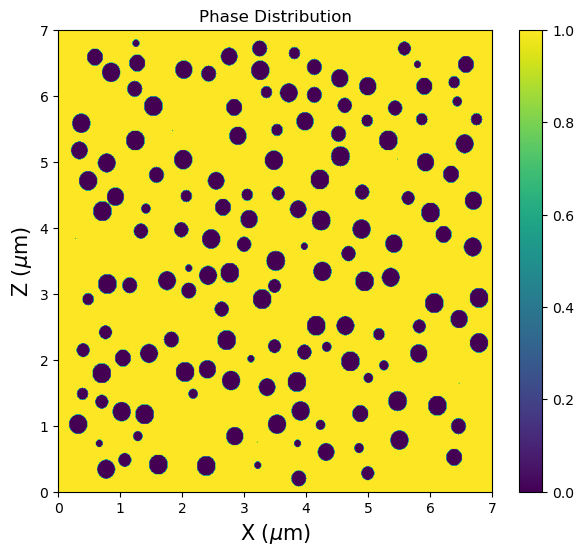

In [ ]:
fig = plt.figure(figsize=(7,6))
ax=fig.add_subplot(1,1,1)
fig = tost.Visualize(X)
fig.plot_distribution(ax)

##### It can be seen that no pore ever interacts with the boundaries.

##### <span style="color:red">Caution! Since this is a 2D slice of a 3D phase distribution, the pores may appear erratically arranged and of different sizes.</span> To better understand the statistics, one can evaluate the 3D spectral density $\tilde{X}(q)$ of the phase distribution.

3D data. Plotting for qy=0 slice


[<Axes: title={'center': 'Reciprocal Space, Spectral density $\\tilde{X}(\\mathbf{q})$'}, xlabel='$q_{x}$ ($\\mu$m$^{-1}$)', ylabel='$q_{y}$ ($\\mu$m$^{-1}$)'>,
 <Axes: xlabel='|q| ($\\mu$m$^{-1}$)', ylabel='$\\tilde{X}(|\\mathbf{q}|)$'>]

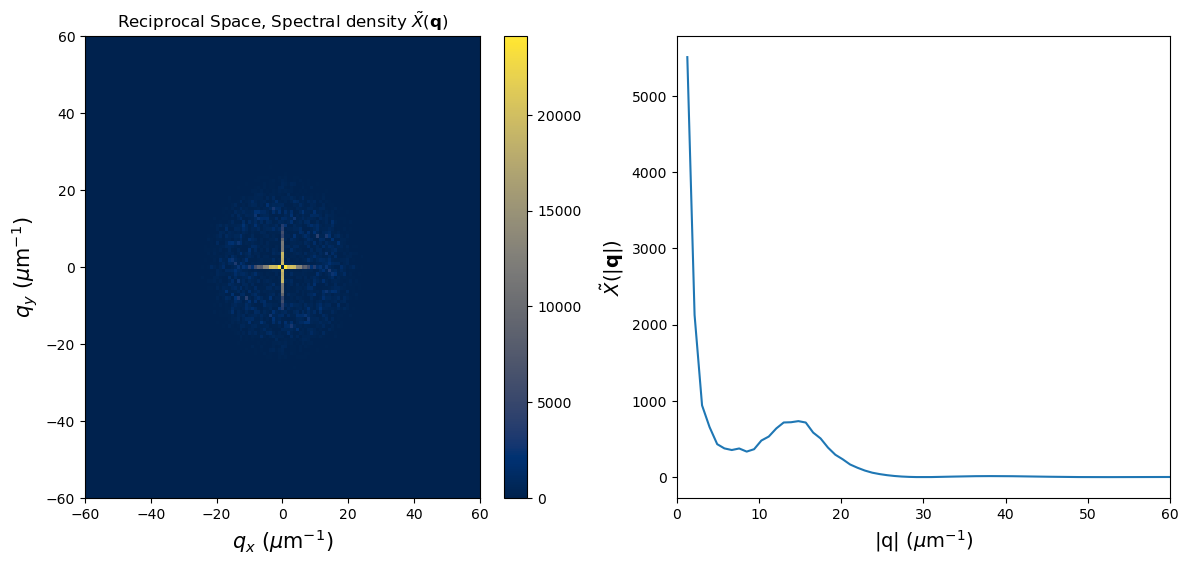

In [9]:
fig.plot_reciprocal_space(vmax=None)

The spectral density contains the same characteristic peak at $q_0=2\pi/0.45\mu m$ as its parent point-process but now has a diverging spectral density towards the origin. This is because the boundaries destroy the long-range statistics (relevant for $q \rightarrow 0$). While this may be problematic for some out-of-plane studies, for in-plane studies where, for example, in-plane forces are applied on the boundaries, this boundary condition is justified because otherwise applied stress and strain would be dependent on number of pores at the boundaries, something that is undesirable.

A periodic-boundary condition (PBC) can also be enforced by conveniently setting `mode='periodic'` above. Although, it should be noted that PBC for such phase distributions is an inherent property of its parent point distribution, and so if the point-distribution does not obey periodicity, neither will its phase distribution.

In [14]:
X = points.Phaseobject(dx=0.015, #resolution decreased only to avoid memory issues in the notebook. For regular .py files, use the same resolution.
                       mode='periodic')

[9.4 9.4 9.4]


3D Data. Plotting for y=3.0 slice


<Axes: title={'center': 'Phase Distribution'}, xlabel='X ($\\mu$m)', ylabel='Z ($\\mu$m)'>

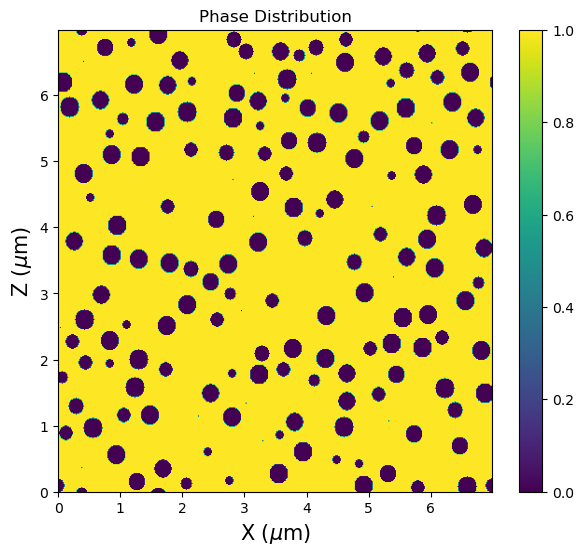

In [ ]:
fig = plt.figure(figsize=(7,6))
ax=fig.add_subplot(1,1,1)

fig = tost.Visualize(X)
fig.plot_distribution(ax)

It can be seen that the boundaries now obey periodic condition. Again, be aware that the periodicity is in 3D and so a 2D slice of a 3D dataset may not accurately show the periodicity. To verify, the correct-ness, one can re-plot the spectral density now.

3D data. Plotting for qy=0 slice


[<Axes: title={'center': 'Reciprocal Space, Spectral density $\\tilde{X}(\\mathbf{q})$'}, xlabel='$q_{x}$ ($\\mu$m$^{-1}$)', ylabel='$q_{y}$ ($\\mu$m$^{-1}$)'>,
 <Axes: xlabel='|q| ($\\mu$m$^{-1}$)', ylabel='$\\tilde{X}(|\\mathbf{q}|)$'>]

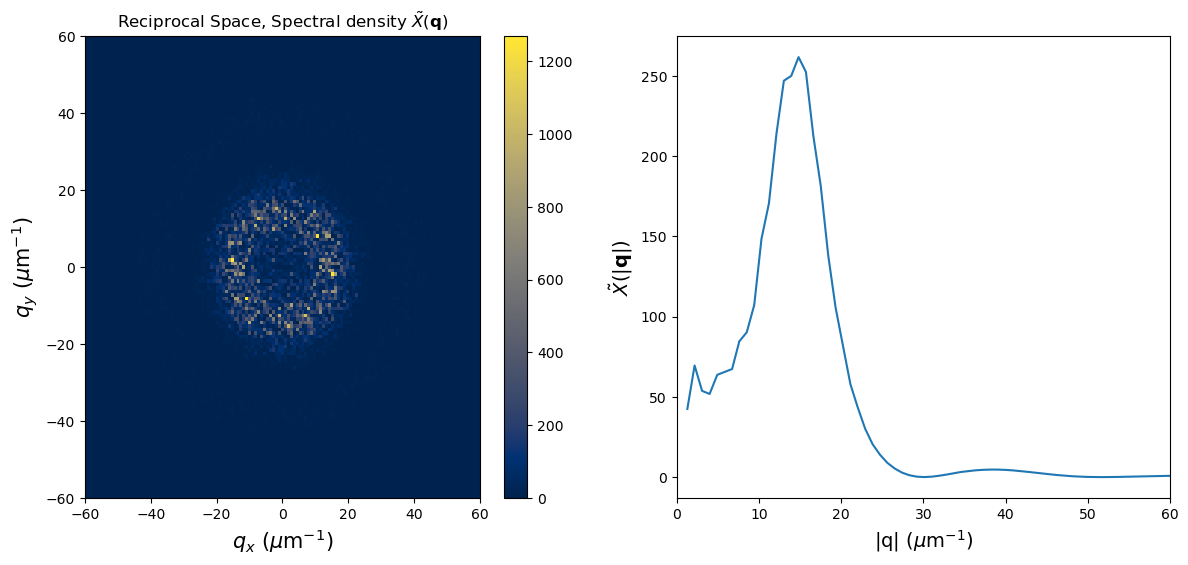

In [16]:
fig.plot_reciprocal_space(vmax=None)

From the angular-averaged spectral density, it can be seen that the diverging peak at $q\rightarrow 0$ in the original case is now gone owing to the periodicity.

***

A 2D counterpart of the above problem can be implemented by simply putting `is_3D=False`.

In [ ]:
process = tost.Pointprocess(BoxSize=7, # Size of the simulation domain. If scalar, chooses Lz based on self.is_3D
                       diameter=0.3, # diameter of the spheres/pores
                       ax = 0.45, # Mean inter-particle distance
                       is_3D = False) # Now 2D

points = process.RandomSequentialAdsorption() # much faster than 3D

Estimated particles to be deposited=241 with mean inter-particle distance=0.45


number of experiments:1583200): |------------------------------| 1.6% Current FF=4.918 of 4.938


<Axes: title={'center': 'Phase Distribution'}, xlabel='X ($\\mu$m)', ylabel='Z ($\\mu$m)'>

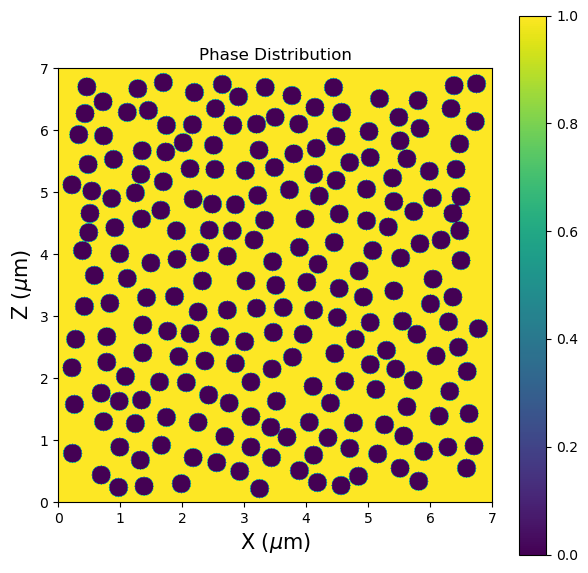

In [ ]:
X = points.Phaseobject(dx=0.01) # resolution : 0.01 microns
fig = tost.Visualize(X)
fig.plot_distribution()

Setting `mode='periodic'` now gives:

[9.4 9.4 0. ]


<Axes: title={'center': 'Phase Distribution'}, xlabel='X ($\\mu$m)', ylabel='Z ($\\mu$m)'>

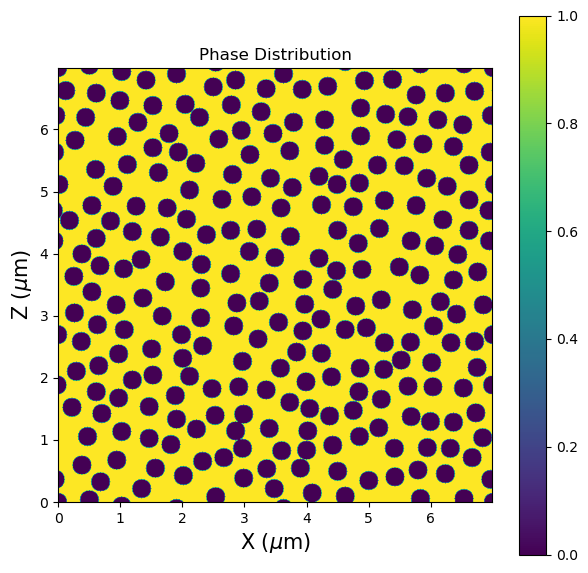

In [ ]:
X = points.Phaseobject(dx=0.01,mode='periodic') # resolution : 0.01 microns
fig = tost.Visualize(X)
fig.plot_distribution()

(699, 699) (699, 699)


[<Axes: title={'center': 'Reciprocal Space, Spectral density $\\tilde{X}(\\mathbf{q})$'}, xlabel='$q_{x}$ ($\\mu$m$^{-1}$)', ylabel='$q_{y}$ ($\\mu$m$^{-1}$)'>,
 <Axes: xlabel='|q| ($\\mu$m$^{-1}$)', ylabel='$\\tilde{X}(|\\mathbf{q}|)$'>]

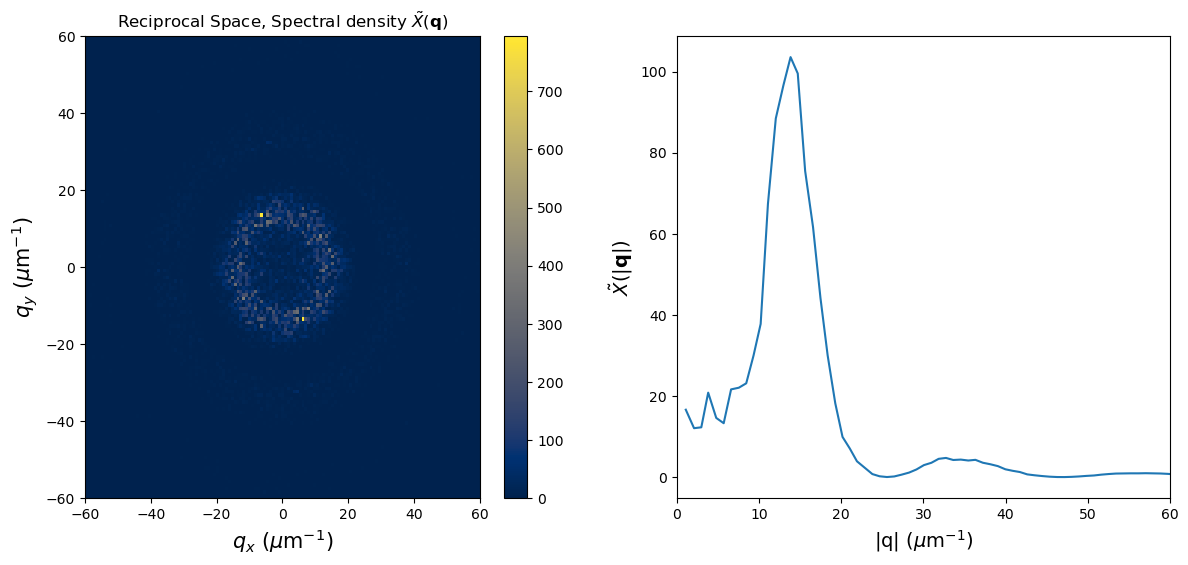

In [20]:
fig.plot_reciprocal_space(vmax=None)

The periodicity check can be done using `PhaseDistribution.tesselate()`

In [21]:
X_ = X.tesselate() # tesselates N copies of original phase distribution 

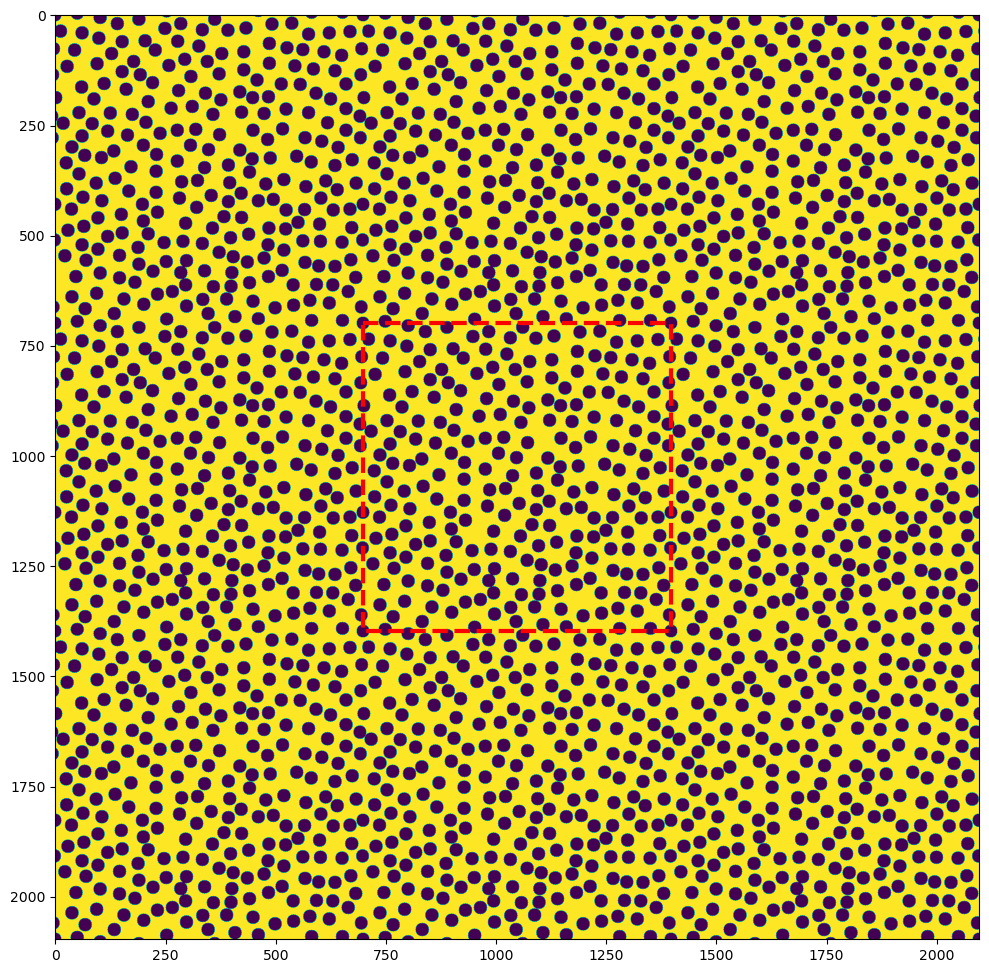

In [22]:
import matplotlib.patches as patches
fig=plt.figure(figsize=(12,12))
ax=fig.add_subplot(1,1,1)
ax.imshow(X_)
box = patches.Rectangle((X.BoxSize[0], X.BoxSize[1]), X.BoxSize[0], X.BoxSize[1], linewidth=3, linestyle='--',edgecolor='red', facecolor='none')
ax.add_patch(box)